# Prediction pool: auditoría, reconstrucción y estado

## TL;DR

- El pool legacy de 58.037.788 filas es inmutable y no se usará para scoring definitivo.
- En 18 regiones, el filtro agregado perdió 1.960/26.369 fuentes compatibles con alguna variante exacta (7,43%); el máximo regional fue 18,90%.
- La corrección es una nueva adquisición inmutable con bitmask versionado y vistas lógicas por variante.
- El build exact-union está en curso; los resultados parciales son progreso de ingeniería, no evidencia científica final.

## Contexto y decisión

El primer pool usó una envolvente agregada construida a partir de loci de varias
variantes. La auditoría demostró que esa envolvente no era un superset
geométrico de su unión exacta. La nueva arquitectura separa:

1. adquisición Gaia por tiles;
2. almacenamiento Parquet inmutable;
3. bitmask de elegibilidad por variante;
4. vistas lógicas reproducibles;
5. scoring resumible por `result_id` sincronizado.

Esta separación permite reintentar consultas sin sobrescribir fuentes y cambiar
la selección de modelos sin volver a descargar toda Gaia.

In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display
import pandas as pd

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)

from wr_detector.reporting.project_summary import (
    AP_LEADER_RESULT_ID,
    LEADING_RESULT_ID,
    STABLE_RESULT_ID,
    collect_evidence,
    generate_figures,
)

PUBLIC_DIR = PROJECT_ROOT / "reports" / "public"
FIGURE_DIR = PUBLIC_DIR / "figures"
evidence = collect_evidence()
figure_paths = generate_figures(evidence, FIGURE_DIR)
display(Markdown(f"**Snapshot local:** `{evidence.snapshot_date}`"))

**Snapshot local:** `2026-07-26`

## Evidencia de la reconstrucción

,valor
run_dir,reports\analysis\prediction_pool_locus_audit\a...
acquisition_sources,44469
current_aggregate_keep,24570
compatible_exact_union_keep,26369
compatible_exact_not_aggregate,1960
loss_fraction,0.07433
regional_max_loss_fraction,0.18902
known_wr_controls,347
known_wr_exact_not_current,2


,valor
status,running
total_tiles,675
completed_tiles,673
running_tiles,0
failed_tiles,2
acquired_rows,184799111
eligible_rows,64875543
parquet_bytes,65877100083
estimated_rows,154000000


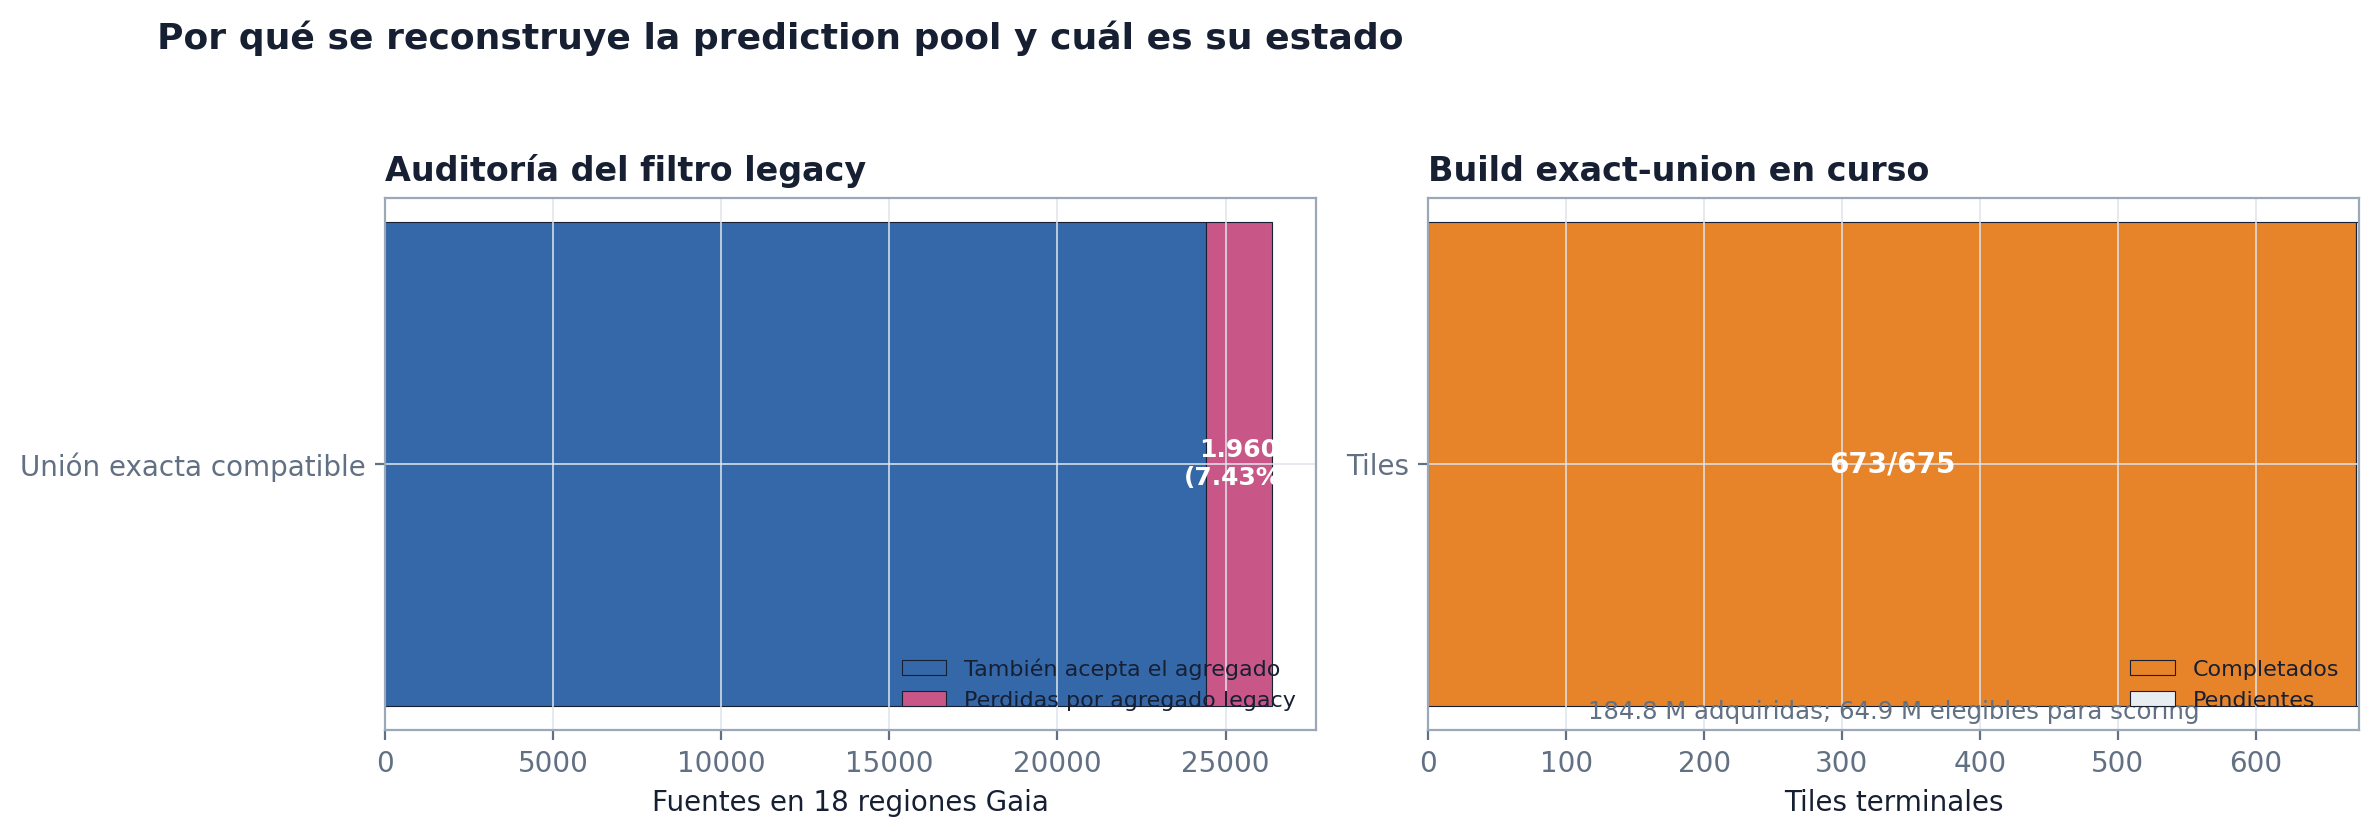

In [2]:
audit = pd.DataFrame([evidence.pool_audit])
status = pd.DataFrame([evidence.pool_status])
display(audit.T.rename(columns={0: "valor"}))
display(status.T.rename(columns={0: "valor"}))
display(Image(filename=str(figure_paths["pool"]), width=1050))

## Alcance y limitaciones

El proyecto consulta todo el cielo, pero restringe la inferencia a una envolvente
amplia de colores observados en WR y después aplica la elegibilidad exacta de
cada variante. No busca recuperar todas las estrellas del plano galáctico ni
usa una ventana espacial como etiqueta.

Las fuentes desconocidas del pool no son negativos confirmados. Por eso el
scoring masivo producirá una lista priorizada para revisión, no una estimación
directa de precisión científica. La confirmación sigue siendo espectroscópica.

## Siguiente secuencia

1. Terminar el build exact-union y ejecutar su auditoría final.
2. Congelar uno o más `result_id` según presupuesto top-K y estabilidad.
3. Validar scoring con `--dry-run` y luego con `--max-tiles 1`.
4. Ejecutar scoring completo y auditar cobertura, hashes y features faltantes.
5. Revisar candidatos con tipos SIMBAD, subtipos WN/WC y segunda capa.
6. Evaluar BP/RP, RVS y H-alpha de Gaia como enriquecimiento opcional.

## Takeaways

La ausencia actual de una lista final no se debe a que falte el método de
scoring: el código, los contratos de linaje y el resume ya existen. El bloqueo
es terminar una adquisición Gaia masiva que preserve la unión exacta y aprobar
su auditoría antes de puntuar.